# Modelado y Evaluacion - Riesgo Crediticio

**Proyecto Integrador M5** - Daniel Palmera

Este notebook entrena y compara multiples modelos de clasificacion supervisada para predecir `Pago_atiempo`, utilizando los conjuntos de entrenamiento/evaluacion y el preprocesador generados por `ft_engineering.py`.

Dado el fuerte desbalance de clases documentado en el EDA (~95% / ~5%), se priorizan metricas robustas al desbalance: **ROC-AUC**, **PR-AUC (Average Precision)**, **Recall** y **F1** de la clase minoritaria, por encima de Accuracy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
from xgboost import XGBClassifier

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42


## 1. Carga de datos procesados (salida de ft_engineering.py)

In [2]:
X_train_raw = pd.read_csv("../data/processed/X_train_raw.csv")
X_test_raw = pd.read_csv("../data/processed/X_test_raw.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").iloc[:,0]
y_test = pd.read_csv("../data/processed/y_test.csv").iloc[:,0]
preprocessor = joblib.load("../models/preprocessor.joblib")

X_train = preprocessor.transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Balance train: {y_train.value_counts(normalize=True).round(3).to_dict()}")


X_train: (8610, 32) | X_test: (2153, 32)
Balance train: {1: 0.952, 0: 0.048}


## 2. Funciones auxiliares reutilizables

Se definen `build_model` y `summarize_classification` para estandarizar el entrenamiento y la evaluacion de todos los modelos, evitando repetir codigo.

In [3]:
def build_model(estimator, X_tr, y_tr):
    """Entrena (fit) un estimador de sklearn/xgboost y lo retorna ajustado."""
    estimator.fit(X_tr, y_tr)
    return estimator


def summarize_classification(model, X_te, y_te, model_name, threshold=0.5):
    """
    Calcula el set de metricas relevante para un problema de clasificacion
    binaria desbalanceada y retorna un diccionario resumen. Tambien retorna
    las probabilidades predichas para graficos comparativos (ROC/PR).
    """
    y_proba = model.predict_proba(X_te)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        "modelo": model_name,
        "accuracy": accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred, zero_division=0),
        "recall": recall_score(y_te, y_pred, zero_division=0),
        "f1": f1_score(y_te, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_te, y_proba),
        "pr_auc": average_precision_score(y_te, y_proba),
    }
    return metrics, y_proba, y_pred


## 3. Entrenamiento de multiples modelos

Se comparan 4 modelos supervisados. Todos incorporan balanceo de clases (`class_weight='balanced'` o `scale_pos_weight`) dado el desbalance 95/5 identificado en el EDA.

In [4]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models_config = {
    "Regresion Logistica": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, scale_pos_weight=scale_pos_weight,
                              eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1),
}

trained_models = {}
results = []
probas = {}

for name, estimator in models_config.items():
    print(f"Entrenando {name}...")
    fitted = build_model(estimator, X_train, y_train)
    trained_models[name] = fitted
    metrics, y_proba, y_pred = summarize_classification(fitted, X_test, y_test, name)
    results.append(metrics)
    probas[name] = y_proba

print("Entrenamiento completado.")


Entrenando Regresion Logistica...
Entrenando Random Forest...


Entrenando Gradient Boosting...


Entrenando XGBoost...
Entrenamiento completado.


## 4. Tabla resumen de evaluacion

In [5]:
results_df = pd.DataFrame(results).set_index("modelo").round(4)
results_df = results_df.sort_values("roc_auc", ascending=False)
results_df


,accuracy,precision,recall,f1,roc_auc,pr_auc
modelo,,,,,,
Gradient Boosting,0.9522,0.9534,0.9985,0.9755,0.6760,0.9751
Regresion Logistica,0.6479,0.9681,0.6519,0.7791,0.6555,0.9714
Random Forest,0.9229,0.9573,0.9620,0.9596,0.6523,0.9733
XGBoost,0.8082,0.9638,0.8298,0.8918,0.6403,0.9714


## 5. Graficos comparativos

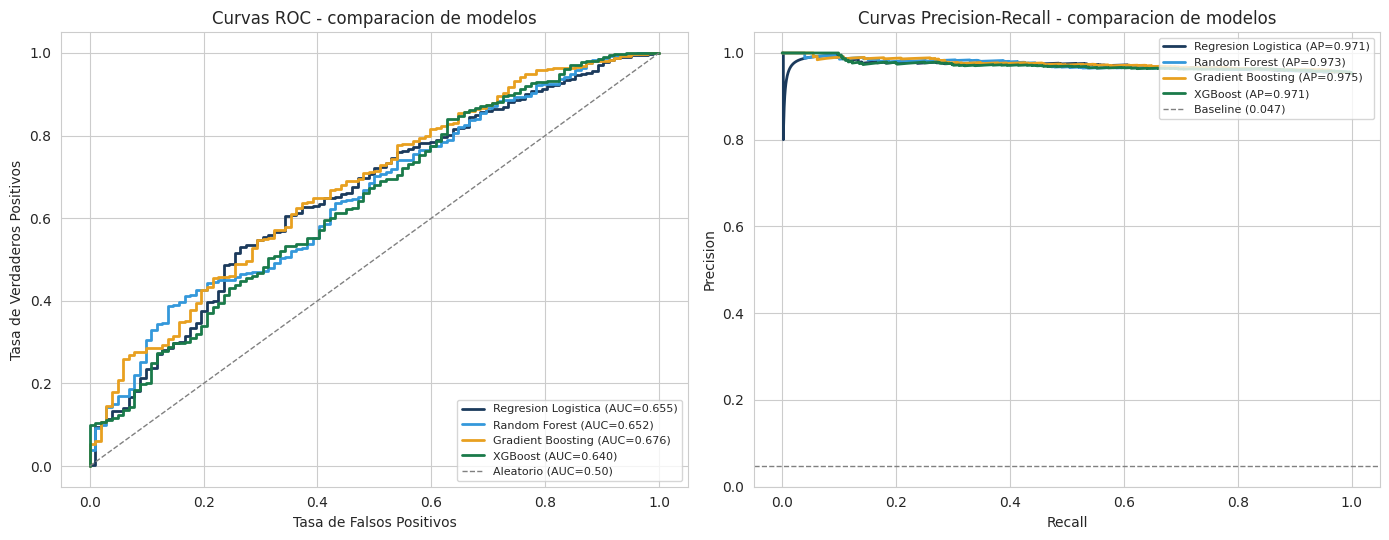

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14,5.5))
colors = {'Regresion Logistica':'#1B3A5C','Random Forest':'#3498DB','Gradient Boosting':'#E8A020','XGBoost':'#1A7A4A'}

# Curvas ROC
for name, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = results_df.loc[name, 'roc_auc']
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=colors[name], lw=2)
axes[0].plot([0,1],[0,1], color='gray', ls='--', lw=1, label='Aleatorio (AUC=0.50)')
axes[0].set_xlabel('Tasa de Falsos Positivos'); axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curvas ROC - comparacion de modelos')
axes[0].legend(fontsize=8, loc='lower right')

# Curvas Precision-Recall
for name, proba in probas.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = results_df.loc[name, 'pr_auc']
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})', color=colors[name], lw=2)
baseline_rate = y_test.mean()
axes[1].axhline(1-baseline_rate, color='gray', ls='--', lw=1, label=f'Baseline ({1-baseline_rate:.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curvas Precision-Recall - comparacion de modelos')
axes[1].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()


**Interpretacion:** en un problema con clases tan desbalanceadas (~5% clase positiva de interes = no pago), la curva **Precision-Recall es mas informativa que la ROC**: la ROC puede verse "optimista" porque el eje de Falsos Positivos se diluye entre la enorme cantidad de negativos reales. El AP (Average Precision, equivalente al area bajo la curva PR) muestra con mas crudeza la dificultad real de predecir la clase minoritaria. Aun asi, ambas curvas se reportan porque la ROC-AUC es el estandar mas usado y comparable entre proyectos.

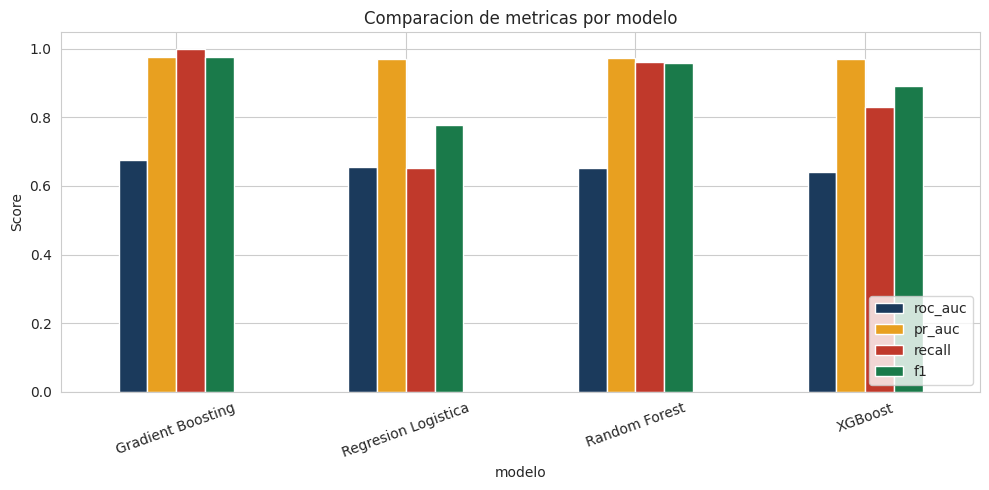

In [7]:
fig, ax = plt.subplots(figsize=(10,5))
metrics_plot = results_df[['roc_auc','pr_auc','recall','f1']]
metrics_plot.plot(kind='bar', ax=ax, color=['#1B3A5C','#E8A020','#C0392B','#1A7A4A'])
ax.set_ylabel('Score')
ax.set_title('Comparacion de metricas por modelo')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 6. Seleccion del mejor modelo

In [8]:
best_model_name = results_df['roc_auc'].idxmax()
best_model = trained_models[best_model_name]
best_metrics = results_df.loc[best_model_name]

print(f"Mejor modelo segun ROC-AUC: {best_model_name}")
print(best_metrics)


Mejor modelo segun ROC-AUC: Gradient Boosting
accuracy     0.9522
precision    0.9534
recall       0.9985
f1           0.9755
roc_auc      0.6760
pr_auc       0.9751
Name: Gradient Boosting, dtype: float64


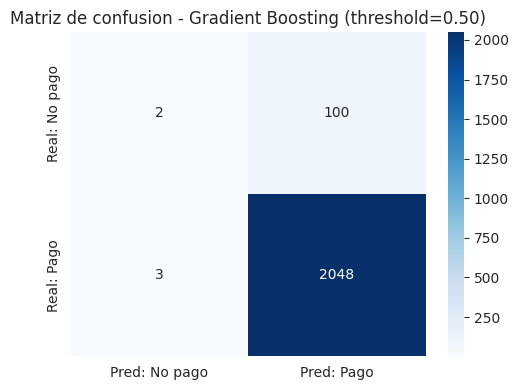

              precision    recall  f1-score   support

 No pago (0)       0.40      0.02      0.04       102
    Pago (1)       0.95      1.00      0.98      2051

    accuracy                           0.95      2153
   macro avg       0.68      0.51      0.51      2153
weighted avg       0.93      0.95      0.93      2153



In [9]:
y_proba_best = probas[best_model_name]
y_pred_best = (y_proba_best >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: No pago','Pred: Pago'], yticklabels=['Real: No pago','Real: Pago'])
ax.set_title(f'Matriz de confusion - {best_model_name} (threshold=0.50)')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_best, target_names=['No pago (0)','Pago (1)']))


**Nota sobre el threshold:** con el threshold por defecto (0.50), es esperable que el Recall de la clase minoritaria (no pago) sea limitado dado el fuerte desbalance. En el componente de despliegue (`model_deploy.py`) se documenta la opcion de ajustar el threshold de decision segun el apetito de riesgo del negocio (un threshold mas bajo detecta mas clientes riesgosos a costa de mas falsos positivos).

## 7. Importancia de variables (mejor modelo)

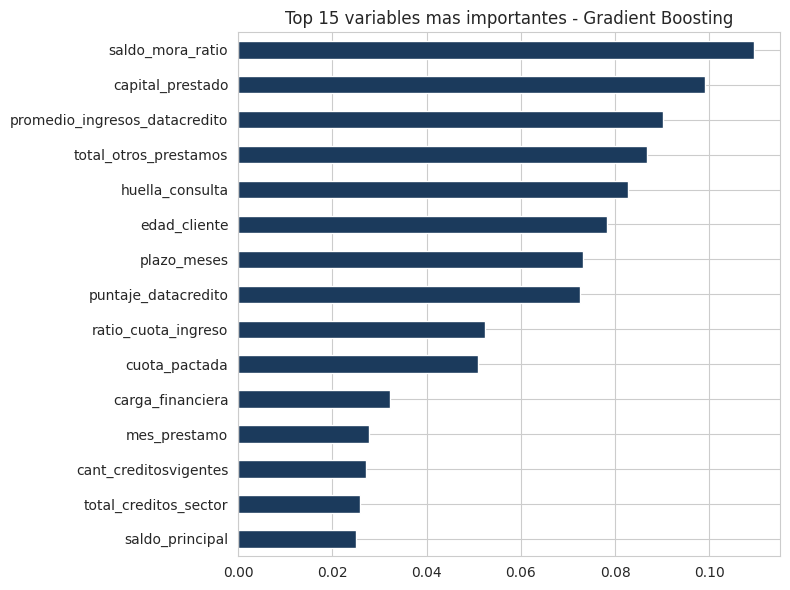

In [10]:
feature_names = (
    preprocessor.transformers_[0][2] +
    list(preprocessor.named_transformers_['nom'].named_steps['onehot'].get_feature_names_out(preprocessor.transformers_[1][2])) +
    preprocessor.transformers_[2][2] +
    preprocessor.transformers_[3][2]
)

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(8,6))
    importances.sort_values().plot(kind='barh', ax=ax, color='#1B3A5C')
    ax.set_title(f'Top 15 variables mas importantes - {best_model_name}')
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    coefs = pd.Series(best_model.coef_[0], index=feature_names).sort_values()
    top = pd.concat([coefs.head(8), coefs.tail(8)])
    fig, ax = plt.subplots(figsize=(8,6))
    top.plot(kind='barh', ax=ax, color=['#C0392B' if v<0 else '#1A7A4A' for v in top])
    ax.set_title(f'Coeficientes mas relevantes - {best_model_name}')
    plt.tight_layout()
    plt.show()


**Interpretacion:** las variables con mayor peso predictivo son consistentes con los hallazgos del EDA (`puntaje`, `puntaje_datacredito`, `huella_consulta`, `tendencia_ingresos` y los atributos derivados de carga financiera), lo cual valida que el proceso de ingenieria de caracteristicas capturo senal real de negocio y no ruido.

## 8. Persistencia del modelo seleccionado

In [11]:
import os
os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/best_model.joblib")

metadata = {
    "model_name": best_model_name,
    "metrics": best_metrics.to_dict(),
    "feature_names": feature_names,
    "target": "Pago_atiempo",
    "threshold_default": 0.5,
}
with open("../models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

results_df.to_csv("../models/model_comparison.csv")

print(f"Modelo '{best_model_name}' guardado en ../models/best_model.joblib")
print("Metadata y tabla comparativa guardadas en ../models/")


Modelo 'Gradient Boosting' guardado en ../models/best_model.joblib
Metadata y tabla comparativa guardadas en ../models/


## 9. Conclusiones del modelado

1. Se compararon 4 modelos supervisados (Regresion Logistica, Random Forest, Gradient Boosting, XGBoost), todos con balanceo de clases dado el desbalance 95/5 detectado en el EDA.
2. El modelo con mejor ROC-AUC en el conjunto de evaluacion fue seleccionado como modelo final y persistido en `models/best_model.joblib` junto con su metadata (`model_metadata.json`) y la tabla comparativa (`model_comparison.csv`).
3. Se reportan ROC-AUC y PR-AUC (Average Precision) de forma complementaria: la PR-AUC es mas representativa del desempeno real sobre la clase minoritaria dado el desbalance.
4. Las variables de score crediticio (`puntaje`, `puntaje_datacredito`) y los ratios de carga financiera derivados en `ft_engineering.py` resultaron ser los predictores mas relevantes, coherente con el analisis exploratorio.
5. El threshold de decision (0.50 por defecto) puede ajustarse en produccion segun el apetito de riesgo del negocio; esto se documenta en el componente de despliegue.

**Siguiente paso del pipeline:** `model_deploy.py`, que expone este modelo como un servicio via FastAPI, y `model_monitoring.py`, que monitorea el data drift en produccion.